In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR


In [2]:
df =pd.read_csv("Encoded insurance_data.csv")

df

,Unnamed: 0,age,gender,bmi,children,smoker,charges
0,0,19,1,27.900,0,1,16884.92400
1,1,18,2,33.770,1,2,1725.55230
2,2,28,2,33.000,3,2,4449.46200
3,3,33,2,22.705,0,2,21984.47061
4,4,32,2,28.880,0,2,3866.85520
...,...,...,...,...,...,...,...
1332,1333,50,2,30.970,3,2,10600.54830
1333,1334,18,1,31.920,0,2,2205.98080
1334,1335,18,1,36.850,0,2,1629.83350
1335,1336,21,1,25.800,0,2,2007.94500


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1337 non-null   int64  
 1   age         1337 non-null   int64  
 2   gender      1337 non-null   int64  
 3   bmi         1337 non-null   float64
 4   children    1337 non-null   int64  
 5   smoker      1337 non-null   int64  
 6   charges     1337 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.2 KB


In [4]:
df.isnull().sum()

Unnamed: 0    0
age           0
gender        0
bmi           0
children      0
smoker        0
charges       0
dtype: int64

In [5]:
df.dropna()

,Unnamed: 0,age,gender,bmi,children,smoker,charges
0,0,19,1,27.900,0,1,16884.92400
1,1,18,2,33.770,1,2,1725.55230
2,2,28,2,33.000,3,2,4449.46200
3,3,33,2,22.705,0,2,21984.47061
4,4,32,2,28.880,0,2,3866.85520
...,...,...,...,...,...,...,...
1332,1333,50,2,30.970,3,2,10600.54830
1333,1334,18,1,31.920,0,2,2205.98080
1334,1335,18,1,36.850,0,2,1629.83350
1335,1336,21,1,25.800,0,2,2007.94500


In [6]:

df['charges'].value_counts()

charges
16884.92400    1
1725.55230     1
4449.46200     1
21984.47061    1
3866.85520     1
              ..
10600.54830    1
2205.98080     1
1629.83350     1
2007.94500     1
29141.36030    1
Name: count, Length: 1337, dtype: int64

In [7]:
x=df.drop('charges', axis=1)
y =df[['charges']]

In [8]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1332,10600.54830
1333,2205.98080
1334,1629.83350
1335,2007.94500


In [9]:
x

,Unnamed: 0,age,gender,bmi,children,smoker
0,0,19,1,27.900,0,1
1,1,18,2,33.770,1,2
2,2,28,2,33.000,3,2
3,3,33,2,22.705,0,2
4,4,32,2,28.880,0,2
...,...,...,...,...,...,...
1332,1333,50,2,30.970,3,2
1333,1334,18,1,31.920,0,2
1334,1335,18,1,36.850,0,2
1335,1336,21,1,25.800,0,2


In [10]:
from sklearn.model_selection import train_test_split

# Assuming you want to split y into train and test sets
x_train , x_test , y_train, y_test = train_test_split(x , y, test_size=0.2, random_state=42)

y_test

,charges
899,8688.85885
1063,5708.86700
1255,11436.73815
298,38746.35510
237,4463.20510
...,...
534,13831.11520
542,13887.20400
759,3925.75820
1283,47403.88000


In [11]:
x_train ,x_test,y_train,y_test = train_test_split(x , y, test_size=0.2, random_state=42)

In [12]:
sv =SVR()

In [13]:
sv.fit(x_train, y_train)

e:\Data science\Python\liet_data\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [14]:
sv.score(x_test,y_test)

-0.13498844219988992

In [15]:
sv.score(x_train, y_train)


-0.10207770454095333

In [16]:
pred=sv.predict(x_test)
pred

array([9290.85576126, 9292.35495245, 9294.69064627, 9290.62904635,
       9291.26507055, 9289.55035723, 9291.0735181 , 9290.6467944 ,
       9289.83941752, 9289.38029832, 9290.58311411, 9290.74296234,
       9294.3583442 , 9291.08668229, 9288.87965376, 9289.36497639,
       9291.33118718, 9293.21839553, 9288.99320851, 9292.85548013,
       9288.51135272, 9289.87471724, 9289.23155314, 9289.15049649,
       9289.74909365, 9292.95731398, 9295.04257995, 9293.82042209,
       9290.37431873, 9290.14760189, 9289.10763037, 9293.59471918,
       9291.65202661, 9291.84905627, 9289.4244336 , 9290.38204889,
       9293.0885286 , 9293.00725264, 9289.96879366, 9289.22412143,
       9292.73083241, 9290.68454259, 9290.74360224, 9294.23225043,
       9289.15492019, 9292.08518145, 9288.7861884 , 9294.62653281,
       9292.95456488, 9293.43756654, 9290.51393388, 9292.5916068 ,
       9293.95853047, 9289.66723324, 9291.22788633, 9292.05929   ,
       9292.12337195, 9292.08606475, 9293.0643688 , 9289.03698

In [17]:
pred[0:20]

array([9290.85576126, 9292.35495245, 9294.69064627, 9290.62904635,
       9291.26507055, 9289.55035723, 9291.0735181 , 9290.6467944 ,
       9289.83941752, 9289.38029832, 9290.58311411, 9290.74296234,
       9294.3583442 , 9291.08668229, 9288.87965376, 9289.36497639,
       9291.33118718, 9293.21839553, 9288.99320851, 9292.85548013])

In [18]:
y_test[0:10]

,charges
899,8688.85885
1063,5708.86700
1255,11436.73815
298,38746.35510
237,4463.20510
481,9304.70190
240,38511.62830
277,2150.46900
415,7345.72660
706,10264.44210


In [19]:
df['charges'].value_counts()

charges
16884.92400    1
1725.55230     1
4449.46200     1
21984.47061    1
3866.85520     1
              ..
10600.54830    1
2205.98080     1
1629.83350     1
2007.94500     1
29141.36030    1
Name: count, Length: 1337, dtype: int64

In [20]:
charges_value_count =df['charges'].value_counts()

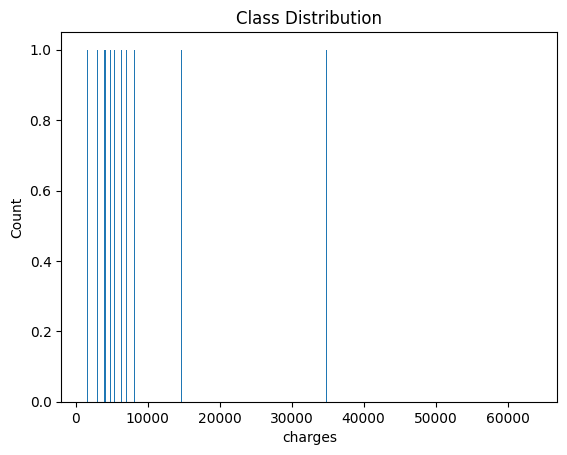

In [21]:
plt.bar(charges_value_count.index, charges_value_count.values)
plt.xlabel('charges')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [22]:
! pip install imblearn
! pip install imbalanced-learn



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier



In [24]:
dtr=DecisionTreeRegressor()
dtr.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [25]:
dtr.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max